In [67]:
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import pandas

In [68]:
# Instantiate spark session
spark = SparkSession.builder \
    .appName("Walmart SQL Analysis") \
    .config("spark.ui.enabled", "false") \
    .getOrCreate()


In [69]:
# Load CSV as DataFrame
df = spark.read.csv("walmart_transformed_real.csv", header=True, inferSchema=True)

# Show the first few rows
df.show()


+-----+----+-----+---+------------+------------+-----------+----------+-----------+------------+-------------+--------------------+-----------+-----------------+
|Month|Year|Store|Day|Weekly_Sales|Holiday_Flag|Temperature|Fuel_Price|        CPI|Unemployment|FormattedDate|FormattedHolidayFlag|HolidayType|Real_Weekly_Sales|
+-----+----+-----+---+------------+------------+-----------+----------+-----------+------------+-------------+--------------------+-----------+-----------------+
|    2|2010|    8| 26|   847592.11|           0|      37.91|     2.561|214.6940735|       6.299|    26-Feb-10|         Not Holiday|Non-Holiday|      394790.6415|
|    9|2010|   16|  3|   542087.89|           0|      58.02|     2.773|190.3621607|       6.868|     3-Sep-10|         Not Holiday|Non-Holiday|      284766.6196|
|    9|2010|   36|  3|   431294.45|           0|      82.29|     2.533|210.2966631|        8.36|     3-Sep-10|         Not Holiday|Non-Holiday|      205088.5847|
|    9|2010|   17|  3|   834

In [70]:
# Register csv as a table
df.createOrReplaceTempView("sales_data")


In [71]:
top_5_store_sales = spark.sql("""
    SELECT Store, SUM(Weekly_Sales) as total_sales
    FROM sales_data
    GROUP BY store
    ORDER BY total_sales DESC
    LIMIT 5
""")

top_5_store_sales.show()

+-----+--------------------+
|Store|         total_sales|
+-----+--------------------+
|   20|      3.0139779246E8|
|    4| 2.995439533799999E8|
|   14|2.8899991134000003E8|
|   13|       2.865177038E8|
|    2|      2.7538244098E8|
+-----+--------------------+



Here we can see the top 5 most productive stores over our time frame. We can see store 20 produced about $300 million in total sales from 2010-2012.

In [72]:
bottom_5_store_sales = spark.sql("""
    SELECT Store, SUM(Weekly_Sales) as total_sales
    FROM sales_data
    GROUP BY store
    ORDER BY total_sales ASC
    LIMIT 5
""")

bottom_5_store_sales.show()

+-----+--------------------+
|Store|         total_sales|
+-----+--------------------+
|   33|3.7160221960000016E7|
|   44| 4.329308784000002E7|
|    5|4.5475688900000006E7|
|   36| 5.341221496999998E7|
|   38| 5.515962642000002E7|
+-----+--------------------+



Here are the total sales for the bottom 5 stores. Store 33 only produced about $37 million in sales.

In [73]:
total_sales = spark.sql("""
    SELECT SUM(Weekly_Sales) AS total_sales
    FROM sales_data
""")

total_sales.show()

+-------------------+
|        total_sales|
+-------------------+
|6.737218987109989E9|
+-------------------+



Here are the total sales over the time period. From 2010-2012, all stores produced a total of about $6.73 billion in sales.

In [74]:
store_20_real = spark.sql("""
    SELECT Year, SUM(Real_Weekly_Sales)
    FROM sales_data
    WHERE Store = 20 AND Month >= 2 AND Month <= 9
    GROUP BY Year
""")

store_20_real.show()

+----+----------------------+
|Year|sum(Real_Weekly_Sales)|
+----+----------------------+
|2012|       3.44413462793E7|
|2010|   3.384310652150001E7|
|2011|  3.4302199809999995E7|
+----+----------------------+



In [75]:
store_20_real_pd = store_20_real.toPandas()
store_20_real_pd.columns = ['Year', 'Total_Real_Weekly_Sales']

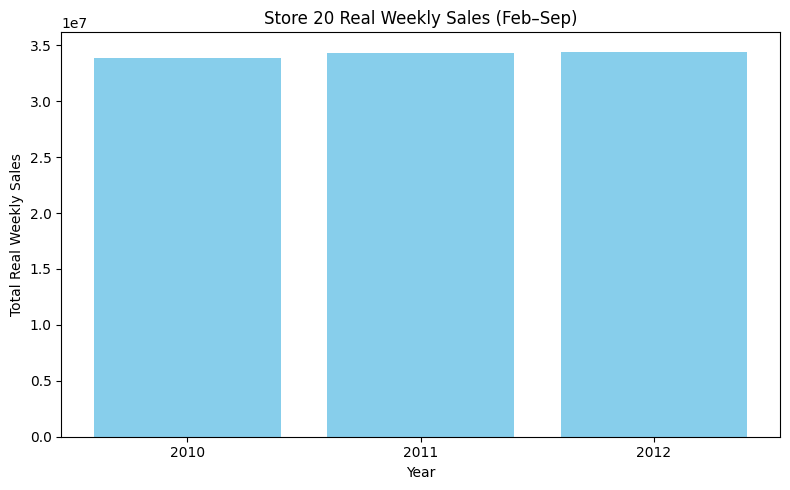

In [76]:
plt.figure(figsize=(8, 5))
plt.bar(store_20_real_pd['Year'], store_20_real_pd['Total_Real_Weekly_Sales'], color='skyblue')
plt.xlabel('Year')
plt.ylabel('Total Real Weekly Sales')
plt.title('Store 20 Real Weekly Sales (Feb–Sep)')
plt.xticks(store_20_real_pd['Year'])
plt.tight_layout()
plt.show()

We want to be able to study how different factors such as CPI, temperature, and unemployment factor into sales. We've already tried to make aggregated visualizations on how these variables affect sales, but we want to try and remove as many confounding variables as possible. We filter out all records except those of store 20, our top store. While the information we learn from store 20 might not always be generalizable, we need to be able to see how individual stores are affected, and it makes sense to make decisions off of our most lucrative stores.

By taking the common period from February to September, we can try to compare the total sales for store 20 year over year. It appears that the amount of sales has remained relatively constant over time with no real growth. Let's compare this with the nominal sales numbers:

In [77]:
store_20 = spark.sql("""
    SELECT Year, SUM(Weekly_Sales)
    FROM sales_data
    WHERE Store = 20 AND Month >= 2 AND Month <= 9
    GROUP BY Year
""")

store_20.show()

+----+-------------------+
|Year|  sum(Weekly_Sales)|
+----+-------------------+
|2012|      7.385732706E7|
|2010|6.915995807000002E7|
|2011|7.141397736000001E7|
+----+-------------------+



In [78]:
store_20_pd = store_20.toPandas()
store_20_pd.columns = ['Year', 'Total_Real_Weekly_Sales']

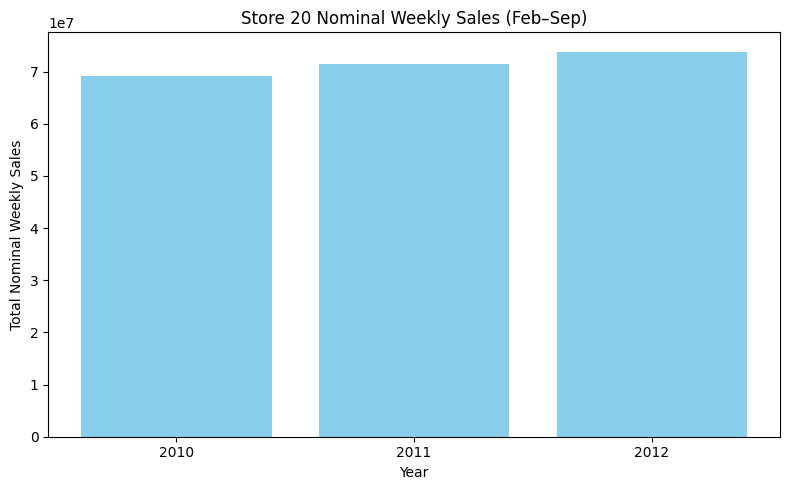

In [79]:
plt.figure(figsize=(8, 5))
plt.bar(store_20_pd['Year'], store_20_pd['Total_Real_Weekly_Sales'], color='skyblue')
plt.xlabel('Year')
plt.ylabel('Total Nominal Weekly Sales')
plt.title('Store 20 Nominal Weekly Sales (Feb–Sep)')
plt.xticks(store_20_pd['Year'])
plt.tight_layout()
plt.show()

In [80]:
sales_data_df = df

In [81]:
christmas_sales = sales_data_df.filter(F.col("HolidayType") == "Christmas")

agg_sales = christmas_sales.groupBy("Store", "Year") \
    .agg(F.sum("Real_Weekly_Sales").alias("Total_Sales"))

sales_pivot = agg_sales.groupBy("Store") \
    .pivot("Year", [2010, 2011]) \
    .sum("Total_Sales") \
    .withColumnRenamed("2010", "Sales_2010") \
    .withColumnRenamed("2011", "Sales_2011")

sales_change = sales_pivot \
    .withColumn("Sales_Change", F.col("Sales_2011") - F.col("Sales_2010")) \
    .withColumn(
        "Percent_Change",
        (F.col("Sales_Change") / F.col("Sales_2010")) * 100
    )

sales_change.show()

+-----+-----------+-----------+-------------------+-------------------+
|Store| Sales_2010| Sales_2011|       Sales_Change|     Percent_Change|
+-----+-----------+-----------+-------------------+-------------------+
|   31|980241.3019|925196.4877|-55044.814199999906| -5.615435106978929|
|   34|1276344.739|1226034.925| -50309.81400000001|-3.9417104535109466|
|   28|1595502.647|1381859.253| -213643.3940000001|-13.390350332649751|
|   26|1185694.346|1109300.023| -76394.32299999986| -6.443003060419407|
|   27| 2253457.93|1949081.208|-304376.72200000007|-13.507095825835988|
|   44|287516.1011|289445.0876|  1928.986499999999| 0.6709142523218499|
|   12| 1392502.78|1244464.861|        -148037.919|-10.631068111763483|
|   22|1436664.874|1325846.477|-110818.39700000011| -7.713587142383221|
|    1|1129561.183|1034925.497| -94635.68599999999| -8.378092964265752|
|   13|2831785.955|2736299.102| -95486.85300000012|-3.3719657670948555|
|   16|525643.4139|484623.1468|-41020.267100000056| -7.803820235

In [82]:
sales_change.toPandas().to_csv("christmas_sales_change.csv", index=False)


In [83]:
spark.stop()